# Sprint 1 — Flower Dataset Exploration & Understanding

## Objective

This notebook examines the Oxford Flowers dataset (102 classes) using the
**same EDA template** as `01_mushroom_dataset_exploration.ipynb`.

Since VisionLab's goal is to run a single pipeline across different datasets,
the section structure (Overview, Statistics, Class Distribution, Path
Validation, Image Size Analysis, Sample Visualization, Integrity Checks) was
deliberately kept identical to the mushroom notebook.

Goals:

- Understand the dataset structure
- Validate image paths
- Analyze class distribution (imbalance is expected here, unlike mushroom)
- Analyze image resolutions
- Detect corrupted or missing images
- Produce a Sprint 1 summary comparing the two datasets

## 2. Imports

In [1]:
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

plt.style.use("ggplot")

## 3. Dataset Configuration

In [2]:
DATASET_ROOT = Path("datasets/extracted/flower_data")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

CAT_TO_NAME_PATH = DATASET_ROOT / "cat_to_name.json"

with open(CAT_TO_NAME_PATH, encoding="utf-8") as f:
    cat_to_name = json.load(f)

print(f"Number of classes in cat_to_name.json : {len(cat_to_name)}")

Number of classes in cat_to_name.json : 102


## 4. Load Dataset

### Dataset Loading

Unlike the mushroom dataset, there's no ready-made CSV here: images are
organized as `train/<class_id>/*.jpg` and `valid/<class_id>/*.jpg`.
`class_id` is the folder name; the actual species name is looked up via
`cat_to_name.json`.

The `test/` folder is **unlabeled** (no subfolders, just a flat file list) —
this comes from Oxford Flowers' original Udacity packaging, where the test
set is provided without class labels. So `test_df` has no `label`/`class_id`
column; the test set can only be used for path/integrity checks.

In [3]:
def build_dataframe(split_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        class_id = class_dir.name
        label = cat_to_name.get(class_id, class_id)
        for img_path in class_dir.glob("*.jpg"):
            rows.append({
                "image_path": str(img_path),
                "local_path": str(img_path),
                "class_id": class_id,
                "label": label,
            })
    return pd.DataFrame(rows)


train_df = build_dataframe(TRAIN_DIR)
val_df = build_dataframe(VAL_DIR)

test_df = pd.DataFrame({
    "image_path": [str(p) for p in sorted(TEST_DIR.glob("*.jpg"))],
})
test_df["local_path"] = test_df["image_path"]

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape} (unlabeled)")
train_df.head()

Train      : (6552, 4)
Validation : (818, 4)
Test       : (819, 2) (unlabeled)


,image_path,local_path,class_id,label
0,datasets\extracted\flower_data\train\1\image_0...,datasets\extracted\flower_data\train\1\image_0...,1,pink primrose
1,datasets\extracted\flower_data\train\1\image_0...,datasets\extracted\flower_data\train\1\image_0...,1,pink primrose
2,datasets\extracted\flower_data\train\1\image_0...,datasets\extracted\flower_data\train\1\image_0...,1,pink primrose
3,datasets\extracted\flower_data\train\1\image_0...,datasets\extracted\flower_data\train\1\image_0...,1,pink primrose
4,datasets\extracted\flower_data\train\1\image_0...,datasets\extracted\flower_data\train\1\image_0...,1,pink primrose


## 5. Dataset Overview

This section summarizes the overall size of the dataset and the number of classes.

In [4]:
total_images = len(train_df) + len(val_df) + len(test_df)

num_classes = train_df["label"].nunique()

print(f"Total Images : {total_images:,}")
print(f"Number of Classes : {num_classes}")

Total Images : 8,189
Number of Classes : 102


## 6. Dataset Statistics

Unlike the mushroom dataset, we expect a **natural imbalance** here — Oxford
Flowers has species with as few as ~40 images and others with 250+.

In [5]:
class_counts = train_df["label"].value_counts()

display(class_counts.describe())
print("Minimum :", class_counts.min())
print("Maximum :", class_counts.max())
print("Mean :", class_counts.mean())
print("Median :", class_counts.median())
print("Std :", class_counts.std())

count    102.000000
mean      64.235294
std       35.399887
min       27.000000
25%       38.000000
50%       53.500000
75%       73.000000
max      206.000000
Name: count, dtype: float64

Minimum : 27
Maximum : 206
Mean : 64.23529411764706
Median : 53.5
Std : 35.39988713708815


## 7. Class Distribution

A bar chart to visually confirm the imbalance.

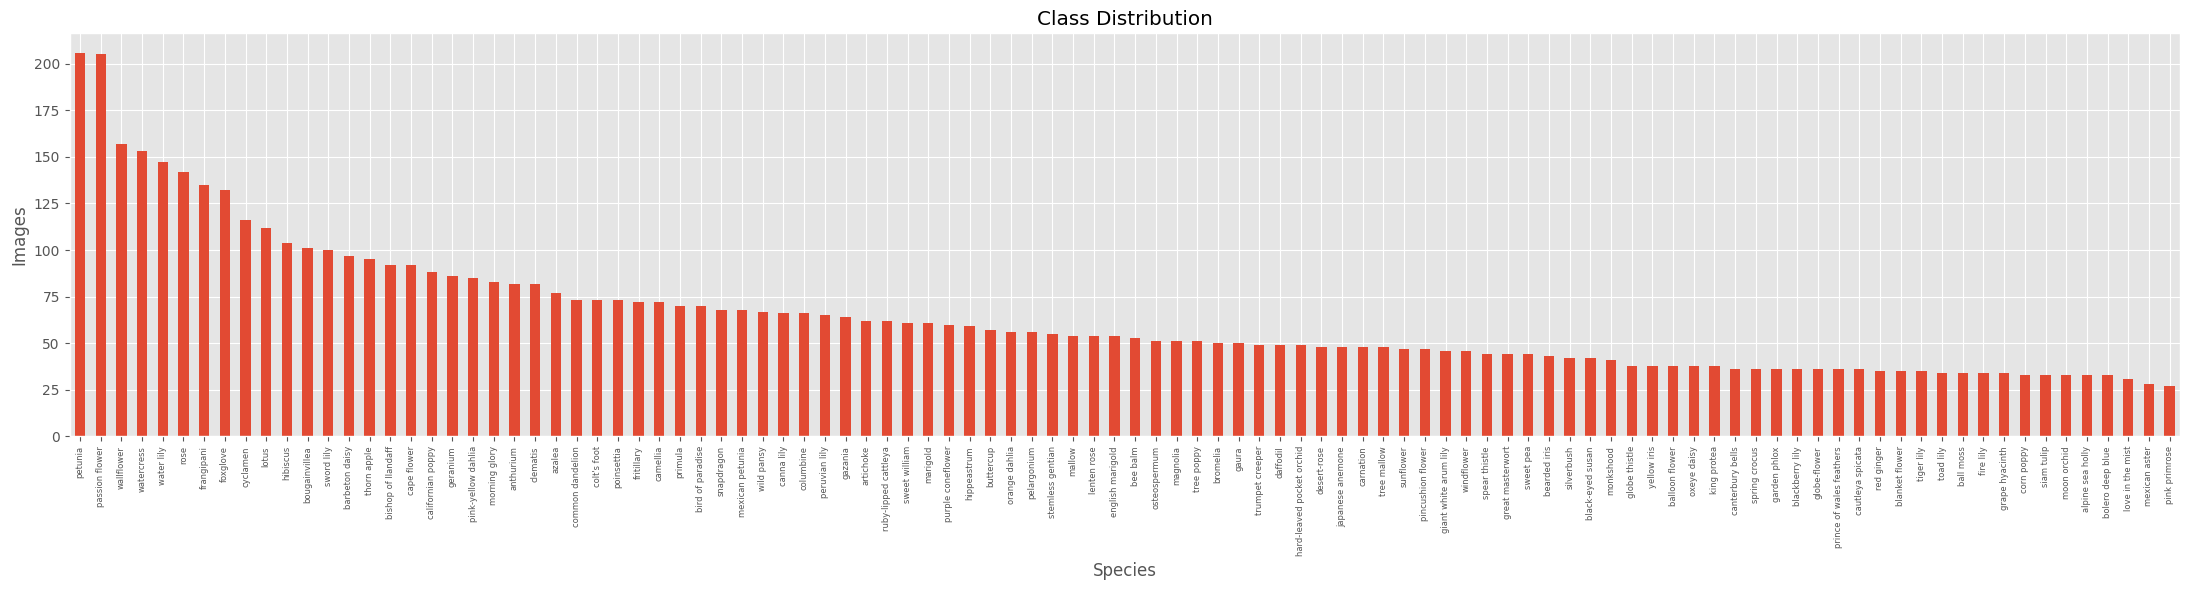

label
petunia           206
passion flower    205
wallflower        157
watercress        153
water lily        147
rose              142
frangipani        135
foxglove          132
cyclamen          116
lotus             112
Name: count, dtype: int64

label
fire lily           34
grape hyacinth      34
corn poppy          33
siam tulip          33
moon orchid         33
alpine sea holly    33
bolero deep blue    33
love in the mist    31
mexican aster       28
pink primrose       27
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(22,6))

class_counts.plot(kind="bar")

plt.xlabel("Species")
plt.ylabel("Images")
plt.title("Class Distribution")
plt.xticks(fontsize=6)

plt.tight_layout()

plt.show()
display(class_counts.head(10))
display(class_counts.tail(10))

## 8. Image Path Validation

Unlike the mushroom dataset, there's no Kaggle-style path rewrite needed
here — the folder structure already matches local paths one-to-one. We still
keep the `local_path` column so that the same Dataset class can work on both
datasets in Sprint 2 (a shared interface). Here we just confirm the files
actually exist.

In [7]:
print("Do the files actually exist?")

exists_train = train_df["local_path"].apply(lambda x: Path(x).exists())
exists_val = val_df["local_path"].apply(lambda x: Path(x).exists())
exists_test = test_df["local_path"].apply(lambda x: Path(x).exists())

print("Train :", exists_train.value_counts().to_dict())
print("Val   :", exists_val.value_counts().to_dict())
print("Test  :", exists_test.value_counts().to_dict())

Do the files actually exist?


Train : {True: 6552}
Val   : {True: 818}
Test  : {True: 819}


## 9. Image Resolution Analysis

Unlike the mushroom dataset, Oxford Flowers doesn't look like it's been
resized to a handful of fixed sizes — since it comes from original photos,
we expect variable resolutions.

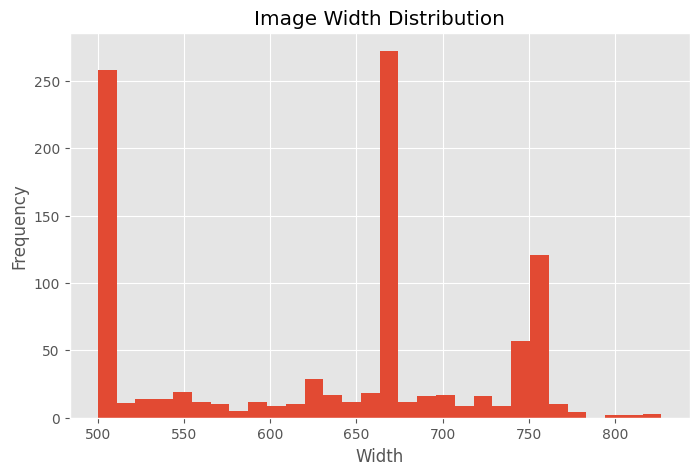

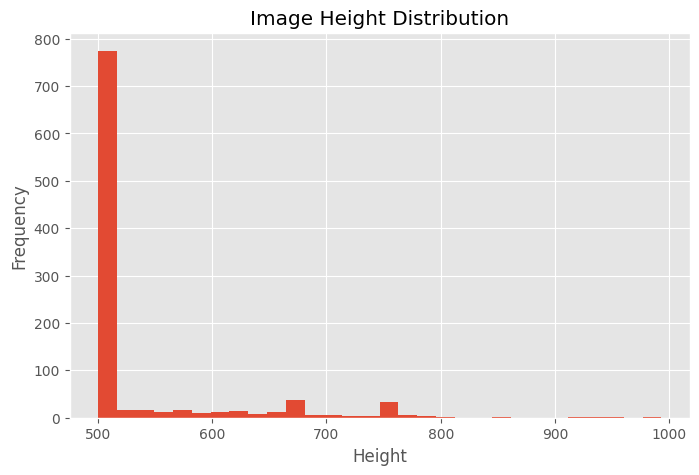

Average Width : 630.006
Average Height : 534.125


In [8]:
sizes = []

sample_paths = random.sample(train_df["local_path"].tolist(), min(1000, len(train_df)))

for path in sample_paths:
    img = Image.open(path)
    sizes.append(img.size)

widths = [w for w,h in sizes]
heights = [h for w,h in sizes]

plt.figure(figsize=(8,5))
plt.hist(widths,bins=30)
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.title("Image Width Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(heights,bins=30)
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Image Height Distribution")
plt.show()

print("Average Width :",np.mean(widths))
print("Average Height :",np.mean(heights))

## 10. Sample Visualization

20 random images with their species label.

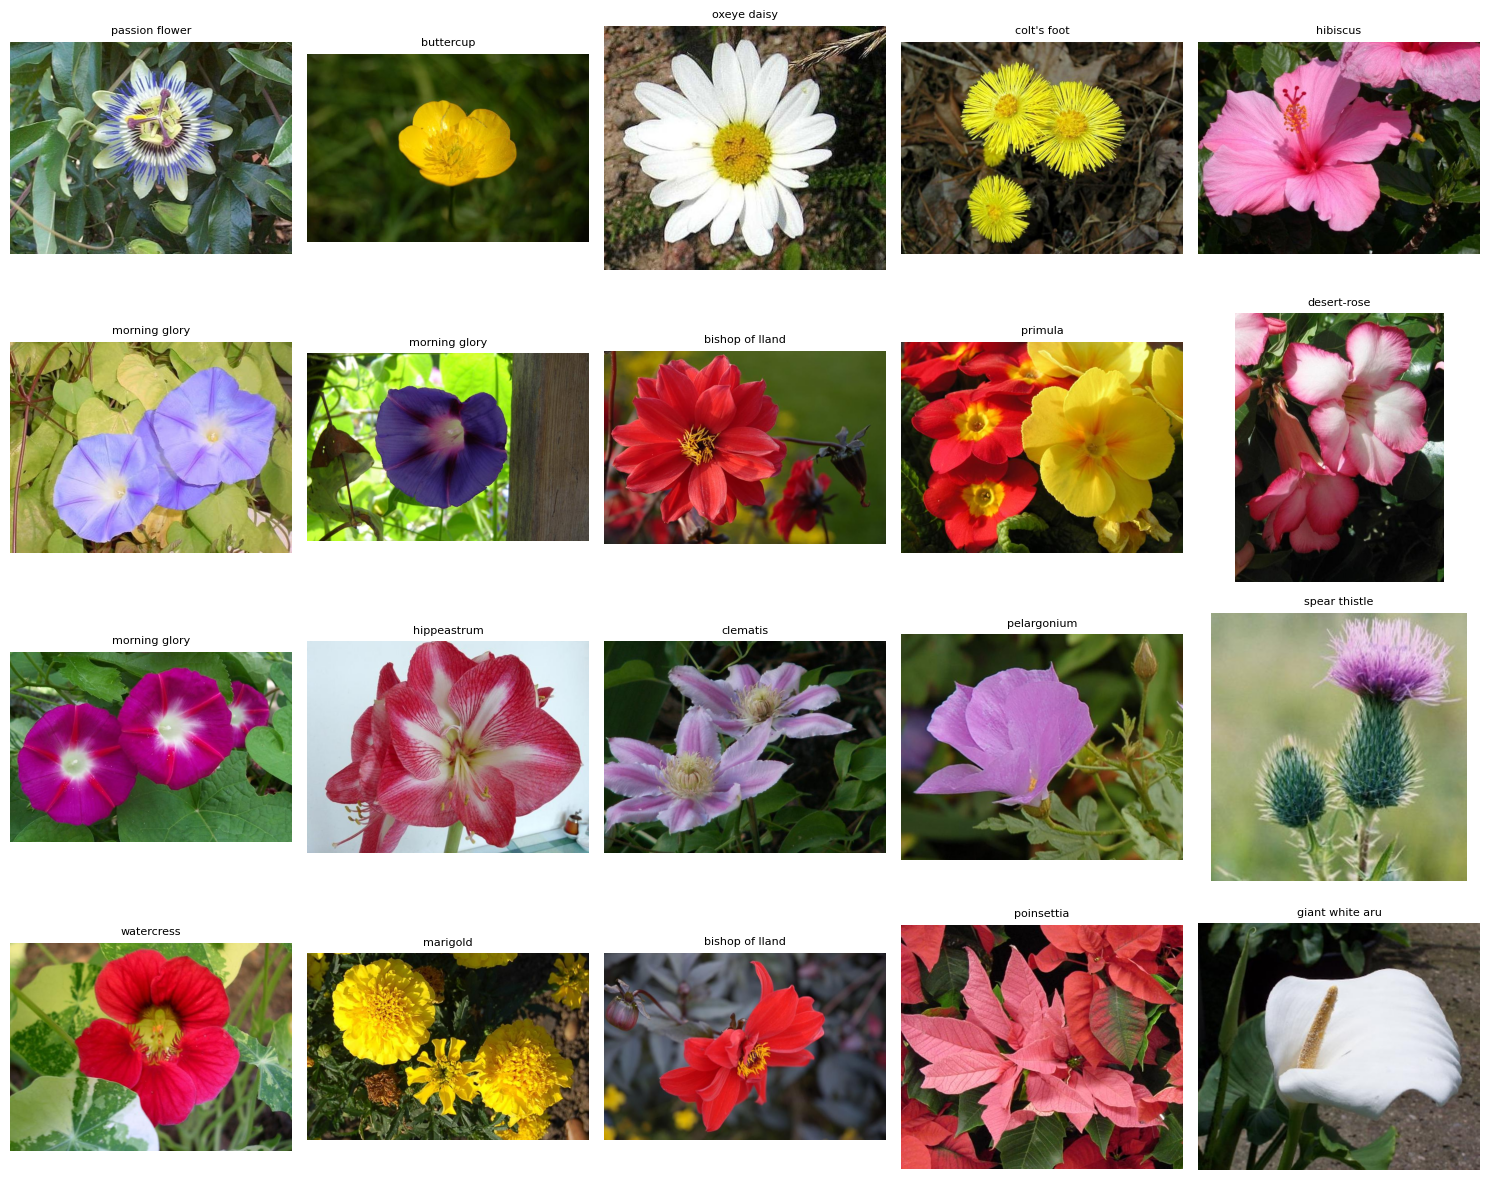

In [9]:
fig,axes = plt.subplots(4,5,figsize=(15,12))

samples = train_df.sample(20)

for ax,(_,row) in zip(axes.flatten(),samples.iterrows()):

    img = Image.open(row["local_path"])

    ax.imshow(img)

    ax.set_title(row["label"][:15],fontsize=8)

    ax.axis("off")

plt.tight_layout()

plt.show()

## 11. Dataset Integrity Checks

Integrity checks across train, validation and test images (sample + full list).

In [10]:
broken=[]

all_paths = train_df["local_path"].tolist() + val_df["local_path"].tolist() + test_df["local_path"].tolist()

for path in random.sample(all_paths, min(3000, len(all_paths))):

    try:
        Image.open(path)

    except Exception:

        broken.append(path)

print("Broken Images :",len(broken))

print("Are there any missing files?")

missing=[]

for path in all_paths:

    if not Path(path).exists():

        missing.append(path)

print("Missing Files :",len(missing))

Broken Images : 0
Are there any missing files?


Missing Files : 0


## 12. Initial Findings — Sprint 1 Summary (Mushroom + Flower Comparison)

### Overall size

8,189 images in total, 102 species. Train/Val/Test: 6,552 / 818 / 819 —
roughly 80% / 10% / 10% (noticeably different from the mushroom dataset's
95.6%/2.2%/2.2% split — the flower dataset allocates a much larger share to
val/test).

### The most important engineering difference: a natural, imbalanced class distribution

The mushroom dataset showed `std = 0.0` (perfect balance); the flower
dataset shows: min = 27, max = 206, mean ≈ 64.2, median = 53.5, std ≈ 35.4.
The largest class is ~7.6x the size of the smallest.

This is the most concrete engineering difference between the two datasets:

| | Mushroom | Flower |
|---|---|---|
| Class balance | Perfect (std=0) | Naturally imbalanced (std≈35.4) |
| `class_weight` / `WeightedRandomSampler` | Unnecessary | Likely necessary |

Consequence: the Training Engine's sampling strategy should be an
**optional parameter, toggleable from config** — not hardcoded. This lines
up directly with the "Training Engine should be fully swappable" goal.

### Path/file integrity — clean for both datasets

For the flower dataset, all of train/val/test (6,552 / 818 / 819) exist
(`True`); across a combined 3,000-image sample, Broken Images: 0, Missing
Files: 0 — the same result as the mushroom dataset. Neither dataset has a
path/integrity blocker going into Sprint 2.

### Image sizes — the two datasets are polar opposites

The mushroom dataset's images clustered around a handful of fixed sizes
(~375/500/625). The flower dataset is the opposite: across a 1,000-image
sample, width ranges 500–833px and height 500–883px in a continuous
distribution (std ≈ 95.5 / 76.8) — no fixed clustering. The fact that the
shorter side is mostly pinned at 500px while the longer side varies suggests
these are original photos that were only downscaled to preserve aspect
ratio.

Practical implication: even with a shared `Dataset`/preprocessing interface,
the resize strategy should behave differently per dataset — mushroom images
are already close in size so aggressive cropping may not be needed, while
flower images will likely benefit more from something like
`RandomResizedCrop`.

### Visual inspection

Flower samples also show some background variety, but not as much "natural
environment" diversity as the mushroom dataset — most images focus tightly
on the flower itself, closer to a studio/close-up style. This suggests the
two datasets may need different augmentation profiles (background/lighting
variation matters more for one than the other).

### Sprint 1 Overall Conclusion

Running the same EDA template on both datasets reveals two complementary
challenge profiles: the mushroom dataset is balanced but visually demands
fine-grained discrimination, while the flower dataset is imbalanced but
visually closer to a standard classification problem. Getting both to run
through the same pipeline (config-driven sampling, a shared Dataset
interface) is the first concrete proof of VisionLab's "modular platform"
goal.

### Data Augmentation — Open Questions (to resolve in Sprint 2 / Benchmark)

No model has been trained yet — that comparison is Benchmark's job. What
belongs here instead are the dataset-specific observations that should
shape the augmentation *hypothesis*, not a conclusion.

**For the mushroom dataset:** class balance is perfect (std=0) and the data
volume is very high (4,080/class), so augmentation here isn't needed to fix
class imbalance — its role is purely regularization and domain robustness.
However, the fact that image resolutions cluster around a few fixed values
(~375/500/625) suggests some of the data may already be processed/duplicated
— until that's confirmed, applying aggressive augmentation risks
"augmenting an augmentation." We should start light (flip, mild color
jitter, small rotations); aggressive geometric transforms like heavy
crop/perspective could distort the fine-grained cues (cap texture, stem
structure) the model needs.

**For the flower dataset:** the situation is reversed — data is scarce
(64 images/class on average, as low as 27 for some classes) and naturally
imbalanced. Here augmentation serves both regularization *and* effectively
increasing diversity for minority classes. Because these images look more
like original photographs (a continuous resolution distribution),
`RandomResizedCrop`-style augmentation likely pays off more here than for
mushroom. Techniques like Mixup/CutMix can also help fight overfitting on
small datasets — these matter less for mushroom.

**Shared conclusion:** which augmentation set actually performs better isn't
an assumption, it's an experiment. The augmentation policy will be exposed
as config-selectable presets (light/medium/heavy), and the real comparison
will happen via an augmentation ablation in the Benchmark sprint.

## 13. Next Steps

Sprint 2 will focus on building a reusable, modular data pipeline that works
for both datasets.

Planned tasks:

- A shared `Dataset` class (using the `image_path` / `local_path` / `label`
  schema for both datasets)
- Path management
- A configuration system (dataset choice, resize target, sampling strategy,
  etc. all read from config)
- Albumentations pipeline
- DataLoader
- Batch visualization
- Pipeline validation

The concrete difference that emerged from the two datasets, to be captured
in config:

- Mushroom dataset is balanced → `WeightedRandomSampler` / `class_weight` unnecessary
- Flower dataset is imbalanced → `WeightedRandomSampler` / stratified sampling may be needed

So the Training Engine will keep the sampling strategy as an **optional,
config-toggleable** parameter.

## 14. Deep-Dive Analysis — Implications of the Findings for Model Design (Mushroom + Flower)

This section summarizes how the findings above should shape architecture and
training decisions in Sprint 2 and beyond, rather than remaining isolated
observations.

### 1. Split ratios — comparison

| | Mushroom | Flower |
|---|---|---|
| Total | 720,750 | 8,189 |
| Train/Val/Test ratio | 95.6% / 2.2% / 2.2% | 80% / 10% / 10% |
| Number of classes | 169 | 102 |
| Average per class | 4,080 | 64.2 |

**Impact:** these two datasets represent nearly opposite scenarios for
modeling — one is "abundant data, balanced," the other "scarce data,
imbalanced." This is actually an ideal contrast for VisionLab's goal of
"comparing different strategies" (a valuable experimental setup, not a
downside). But the practical consequences differ:

- **For mushroom:** no need for aggressive transfer learning — there's
  enough data to train from scratch; fine-tuning large models (ConvNeXt,
  ViT) is safe.
- **For flower:** 64 samples/class on average, as low as 27 (min) — training
  a large model from scratch here is close to a guaranteed overfitting.
  Freezing the backbone and training only the head (linear probing), or
  fine-tuning with a very low learning rate plus strong regularization
  (dropout, label smoothing, mixup/cutmix), becomes mandatory. This is
  exactly where the Benchmark's "Transfer Learning / Fine-tuning / Freeze"
  axis will actually matter for the flower dataset.

### 2. Class balance — the most critical difference

Mushroom: `std=0`; flower: `std≈35.4`, min 27 – max 206 (~7.6x difference).

**Concrete impact on modeling:**

- On the flower dataset, plain accuracy is misleading — a model can ignore
  minority classes (e.g. pink primrose: 27, mexican aster: 28) and still
  look good by favoring majority classes. Reporting macro-F1 or balanced
  accuracy will be more reliable than plain accuracy — this needs to be
  called out explicitly in the Evaluation section.
- `WeightedRandomSampler` or class-weighted loss
  (`CrossEntropyLoss(weight=...)`) is a strong candidate for flower;
  unnecessary for mushroom. Keeping this config-toggleable is the right call.

**A risk that's easy to miss:** the flower val set has 818 images / 102
classes → ~8 samples/class on average, but because the distribution is
imbalanced, some classes may only have 2–3 images in val. This makes
per-class metrics (especially for minority classes) very noisy — a model
can look "bad" just because of 1–2 wrong predictions.

**Recommendation:** add a cell in Sprint 2 that checks the minimum
per-class sample count in the flower val set
(`val_df["label"].value_counts().min()`), and if it's very low (e.g. <5),
report benchmark results with confidence intervals or averaged across
multiple seeds — otherwise model comparisons ("ResNet vs EfficientNet vs
ViT") could mistake noise for a real difference. This matters for the
scientific validity of the "small-scale academic study" goal.

### 3. The flower test set problem — a critical point not to miss

The flower test set is unlabeled (819 images, no labels) — this comes from
Oxford Flowers' Udacity packaging.

**Impact:** we can't report a final "test accuracy" — this is a real gap for
a portfolio project, since the Benchmark/Tracking stage will need to state
"the model's real performance." Two options:

1. Find the original Oxford Flowers 102 dataset's official `imagelabels.mat`
   file and match it to these test images (need to check whether filenames
   allow this mapping).
2. Or re-split train/val (e.g. a stratified 70/15/15) to create our own
   labeled test set.

This decision should be made now — otherwise we'll have to circle back to
solve it during the Benchmark sprint. Noting it now is more efficient.

### 4. Path format — a risk that could silently break things later

In the flower notebook, paths are in Windows format
(`datasets\extracted\flower_data\train\1\...`) with `\`. The mushroom
notebook uses `/` (POSIX-style).

**Impact:** at deployment time (FastAPI + Docker, likely a Linux container),
Windows-style string paths can break. Even though we use `pathlib.Path`, the
`local_path` column is stored as a plain string (`str(img_path)`), so a
CSV/pickle produced on Windows may not work on Linux.

**Recommendation:** in Sprint 2, always normalize paths through `Path()`
inside the `Dataset` class — don't store raw strings.

### 5. Image resolution — two different origin stories

- **Mushroom:** clustered around a few fixed sizes (~375/500/625) → likely
  already resized from a processed source, so the real diversity may be
  lower than it appears (duplicate/near-duplicate risk — the open question
  raised earlier still stands).
- **Flower:** ~631x531 on average, a continuous/spread-out distribution (no
  clear clustering in the histogram) → closer to original photographs,
  likely higher real diversity.

**Impact:** blindly applying the same resize strategy to both datasets is
risky. Flower will likely benefit more from `RandomResizedCrop` (real
diversity is high); for mushroom, keeping augmentation more conservative
makes sense until the original/duplicate question is resolved.

**Additional risk — aspect ratio distortion:** in both datasets, images
aren't square. A direct, non-aspect-preserving `Resize(224,224)` can distort
the fine-grained shape cues (mushroom cap, flower petal) that matter for
classification. `Resize` + `CenterCrop` (preserves aspect ratio) or a
letterbox-padding strategy should be standard for both datasets in Sprint 2.

### 6. Good news for the shared platform design

Keeping the `local_path` / `label` schema identical across both datasets
(even though one comes from a CSV and the other from folder structure) is
the right architectural call. If Sprint 2 delivers a single `Dataset` class
with `num_classes` and `sampling_strategy` read from config, the "same
pipeline, different dataset" claim becomes concrete.